# Experiment 4.3 — Annealing the Feature Weight

Notebook 4.2 measured two opposing pulls on `beta`, the weight of the feature block
relative to position in append-mode matching:

- the **more misaligned** the clouds, the higher it should be — position carries no
  usable signal until they roughly overlap (best `beta` was 0 at 0°, ≥8 at 150°);
- the **more degraded** the observation, the lower it should be — a perturbed descriptor
  given full authority locks in wrong correspondences with no position signal left to
  overrule them (best `beta` was 5 when clean, 0.25 when severe).

Degradation is a property of the data and fixed for a run, so it sets a **ceiling**.
Misalignment shrinks as ICP converges, so the right value *moves* underneath that ceiling
— and no constant can follow it. `beta = 3` has been used throughout this project as the
compromise between the two.

This notebook asks whether varying `beta` over a run beats that compromise, and on which
axis. Two things could improve, and they are not the same:

| | what it measures | which pull it comes from |
|---|---|---|
| **reliability** | fraction of seeds reaching the global optimum | high `beta` early — finding the basin |
| **accuracy** | true residual among the runs that got there | low `beta` late — refining inside it |

| § | Question |
|---|---|
| 1 | What does a run actually look like? Calibrating the triggers. |
| 2 | Do the schedules beat the best constant, across degradation levels? |
| 3 | How sensitive is each schedule to its starting `beta`? |

In [ ]:
import sys
sys.path.insert(0, '../src')

from typing import Any

import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from tqdm import tqdm

from error_metrics import true_residuals
from experiment_runner import fit_multi_seed
from feature_extractor import GeometricFeatureExtractor
from icp import (
    ICP,
    ICPCallback,
    ConsistencyBetaAnnealing,
    DeltaBetaAnnealing,
    IterationBetaAnnealing,
    ResidualBetaAnnealing,
    TwoPhaseBetaAnnealing,
)
from matcher import NearestNeighborMatcher
from synthetic import PerfectObserver, PointCloudObserver, SyntheticExperiment
from visualization import SweepVisualizer

plt.style.use('seaborn-v0_8-whitegrid')

CLOUD_STYLE = 'clustered'
N_SEEDS = 50
N_POINTS = 500
MAX_ITER = 400
TOL = 1e-6
FE_K = 40          # neighbourhood size, from notebook 4.1
BETA_BASELINE = 3.0  # the constant compromise, from notebook 4.2

GEN_KWARGS: dict[str, Any] = dict(n=N_POINTS, t_scale=8.0, style=CLOUD_STYLE)
SPACING = SyntheticExperiment.generate(**GEN_KWARGS, seed=0).P.median_spacing

# Hard matching throughout: notebook 4.1 showed it matches the soft, sigma-annealed
# matcher once features are present, at a fraction of the cost.
CLEAN_TOL = 1e-3
DEGRADED_TOL = 0.5 * SPACING

DEGRADATION_LEVELS: dict[str, dict[str, float]] = {
    'clean':    dict(noise_std=0.00, dropout_prob=0.00),
    'mild':     dict(noise_std=0.10, dropout_prob=0.05),
    'moderate': dict(noise_std=0.20, dropout_prob=0.10),
    'heavy':    dict(noise_std=0.40, dropout_prob=0.20),
    'severe':   dict(noise_std=0.70, dropout_prob=0.30),
}

print(f'point spacing {SPACING:.2f} | clean tol {CLEAN_TOL} | degraded tol {DEGRADED_TOL:.2f}')

point spacing 2.00 | clean tol 0.001 | degraded tol 1.00


In [2]:
def build_icp(schedule: ICPCallback | None, beta: float = BETA_BASELINE) -> ICP:
    """Build the ICP under test, optionally driven by a beta schedule.

    Args:
        schedule: Beta-annealing callback, or None for a constant beta.
        beta:     Constant feature weight, and the matcher's starting value when a
                  schedule is given (the schedule overwrites it each iteration).

    Returns:
        A configured hard-matching ICP.
    """
    matcher = NearestNeighborMatcher(
        feature_extractor=GeometricFeatureExtractor(k=FE_K), beta=beta,
    )
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL,
               callbacks=[schedule] if schedule is not None else [])


def evaluate(
    schedule: ICPCallback | None,
    degradation: dict[str, float],
    tol: float,
    beta: float = BETA_BASELINE,
) -> tuple[float, float]:
    """Score one schedule under one degradation regime.

    Reliability and accuracy are reported separately because the two pulls on beta act
    on different ones: a high beta early is what finds the basin, a low beta late is
    what refines inside it. A schedule could improve either without the other, and
    collapsing them into a single number would hide which.

    Args:
        schedule:    Beta-annealing callback, or None for a constant beta.
        degradation: Forwarded to PointCloudObserver.
        tol:         Mean-true-residual threshold separating success from a wrong basin.
        beta:        Constant weight, or the schedule's starting weight.

    Returns:
        Tuple (reliability, median true residual among successful seeds). The residual
        is NaN when no seed succeeded.
    """
    observer = PointCloudObserver(**degradation)
    result = fit_multi_seed(
        build_icp(schedule, beta), list(range(N_SEEDS)),
        experiment_kwargs=GEN_KWARGS, observer=observer.reset(), verbose=False,
    )
    residuals = np.array(result.mean_true_residuals)
    reached = residuals < tol
    return float(reached.mean()), float(np.median(residuals[reached])) if reached.any() else float('nan')


def tolerance_for(level: str) -> float:
    """Success threshold for a degradation level.

    Dropout leaves the two sides holding different subsets of points, so the transform
    fitted on them is biased with respect to the exact clouds the residual is scored
    against; even a correct run cannot reach the noiseless floor. A clean run can.

    Args:
        level: Key into DEGRADATION_LEVELS.

    Returns:
        The mean-true-residual threshold to use.
    """
    return CLEAN_TOL if level == 'clean' else DEGRADED_TOL

## 1. What does a run look like?

A schedule needs a trigger, and a trigger needs a scale. Two candidate signals are
available inside a run, and this section measures what they actually do before either is
used to drive anything.

- **ICP's own residual** — the mean distance from each matched source point to its
  matched target. Note what this is *not*: it is a closest-point residual, so it stays
  small even in a completely wrong basin, because nearest-neighbour matching always
  finds *some* nearby point. Normalising by the cloud's point spacing at least makes it
  scale-free.
- **The windowed delta** — ICP's own convergence measure, how far the composition of the
  last ten steps is from the identity. It answers "is the transform still moving", which
  is a different question from "is it right".
- **The distinct-target fraction** — how many separate target points the correspondences
  claim, over the number of source points. A correct alignment pairs roughly one-to-one;
  a wrong one collapses many source points onto the same few targets. This is the only
  one of the three that measures correspondence quality rather than a distance.

In [3]:
observer = PointCloudObserver(**DEGRADATION_LEVELS['moderate'])
rows = []
for seed in (0, 1, 2):
    experiment = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed)
    degraded = observer.reset()
    source, target = degraded.observe(experiment.P), degraded.observe(experiment.Q)
    # Record the correspondence-quality signal alongside the geometric ones.
    seen: list[float | None] = []

    class _Watch(ICPCallback):
        def on_iteration_start(self, progress, icp):
            seen.append(progress.match_uniqueness)

    icp = build_icp(None)
    icp.callbacks = [_Watch()]
    result = icp.fit(source, target)
    # Scored against the exact clouds, which is what "right basin" actually means.
    truth = [float(true_residuals(T.apply(experiment.P), experiment.Q).mean())
             for T in result.transform_history]
    for i in list(range(6)) + [result.n_iterations - 1]:
        uniqueness = seen[i + 1] if i + 1 < len(seen) else seen[-1]
        rows.append([seed, i, f'{result.mean_residuals[i] / SPACING:.2f}',
                     f'{result.deltas[i]:.2e}',
                     '-' if uniqueness is None else f'{uniqueness:.2f}',
                     f'{truth[i]:.3f}'])
    rows.append(['', '', '', '', '', ''])

print(f"Constant beta={BETA_BASELINE}, moderate degradation, first iterations and the last\n")
print(tabulate(rows, headers=['seed', 'iter', 'ICP resid / spacing', 'delta',
                              'distinct targets', 'true resid'],
               tablefmt='rounded_outline'))

Constant beta=3.0, moderate degradation, first iterations and the last

╭────────┬────────┬───────────────────────┬───────────┬────────────────────┬──────────────╮
│   seed │   iter │   ICP resid / spacing │     delta │   distinct targets │   true resid │
├────────┼────────┼───────────────────────┼───────────┼────────────────────┼──────────────┤
│      0 │      0 │                  4.56 │ 29.6      │               0.6  │        3.625 │
│      0 │      1 │                  2.85 │ 28.2      │               0.62 │        1.077 │
│      0 │      2 │                  2.77 │ 27.9      │               0.62 │        0.81  │
│      0 │      3 │                  2.74 │ 27.7      │               0.63 │        0.77  │
│      0 │      4 │                  2.75 │ 27.6      │               0.63 │        0.804 │
│      0 │      5 │                  2.74 │ 27.5      │               0.63 │        0.823 │
│      0 │     17 │                  2.72 │  2.48e-14 │               0.63 │        0.841 │
│       

### Observations — calibration

**The search is short, but not as short as it first looks.** Seeds 0 and 1 reach their
final true residual within 2–3 iterations; seed 2 takes 5, starting from a true residual
of 20 and only crossing into the right basin around iteration 3–4. A schedule that
anneals on a fixed iteration count has to be slow enough for the seed 2 case, which is
precisely the information an open-loop schedule cannot have.

**None of the three signals reaches the value one would naively assume.**

| signal | at the start | where it settles |
|---|---|---|
| ICP residual / spacing | 4.6–7.1 | **2.4–2.7**, not 1 |
| windowed delta | 10–30 | collapses to ~1e-14, but only after ~10 iterations |
| distinct-target fraction | 0.50–0.60 | **0.63–0.65**, not 1 |

This matters more than it sounds. A schedule interpolating towards an endpoint the signal
never reaches simply *stops part-way* and becomes a lower constant — annealing in name
only. Both threshold-based schedules were initially configured that way (`end_spacings=1`,
`end_uniqueness=0.9`) and are calibrated here to what the signals actually do.

**Why the residual settles so high.** It is a *closest-point* residual: nearest-neighbour
matching always finds *some* nearby target, so the value reflects the local point density
far more than the quality of the alignment. Seed 2 at iteration 0 sits at 7.1 spacings
with a true residual of 20, and at iteration 5 at 2.55 spacings with a true residual of
1.0 — a factor of 20 in real error compressed into a factor of 3 in the observed signal.

**Why the delta is large early for the wrong reason.** `_windowed_delta` composes the last
ten steps, or the whole run when fewer than ten have elapsed. For the first ten iterations
it therefore measures displacement from the origin rather than recent motion, and reads
large regardless. Harmless here — it holds `beta` up through exactly the iterations where
the search happens — but it is an artifact, not a measurement.

## 2. Do the schedules beat the best constant?

Five schedules, against the constant `beta` that notebook 4.2 settled on, across the
degradation range. They differ only in what they use to decide how far along the run is.

| schedule | signal | what it really asks |
|---|---|---|
| `IterationBetaAnnealing` | iteration count | *assumes* misalignment shrinks with time |
| `ResidualBetaAnnealing` | residual / point spacing | how far off am I, in units of the data |
| `DeltaBetaAnnealing` | delta / this run's peak delta | am I still moving |
| `ConsistencyBetaAnnealing` | fraction of distinct targets claimed | are my correspondences any good |
| `TwoPhaseBetaAnnealing` | delta crossing a threshold | a switch, not a curve |

The first is open-loop: it never looks at the fit, so it cannot latch, but equally it
gives a stalled run no extra help and strips `beta` from one that has not found the basin
yet. The middle three close the loop on progressively less indirect signals — the
residual is a *closest-point* residual and stays small even in a wrong basin, the delta
asks whether the transform is still travelling rather than whether it is right, and only
the consistency fraction measures correspondence quality itself. The last is the baseline
a graded schedule must justify itself against: if two regimes capture the benefit, a
smooth curve is complexity without payoff.

All are clamped non-increasing. Every closed-loop variant risks a latch — a high `beta`
produces bad correspondences, which keeps the signal pinned, which keeps `beta` high —
and forbidding increases removes that failure mode.

In [4]:
# Thresholds calibrated from section 1, which is what that section is for. Two of them
# were initially set to values the signals never reach: the closest-point residual
# plateaus around 2.4-2.7 spacings rather than falling to 1, and the distinct-target
# fraction tops out near 0.65 rather than 0.9. A schedule whose endpoint is unreachable
# never finishes annealing, which silently turns it back into a (lower) constant.
SCHEDULES: dict[str, ICPCallback | None] = {
    f'constant beta={BETA_BASELINE:g}': None,
    'iteration 3 -> 0': IterationBetaAnnealing(BETA_BASELINE, 0.0, MAX_ITER),
    'residual 3 -> 0': ResidualBetaAnnealing(BETA_BASELINE, 0.0,
                                             start_spacings=5.0, end_spacings=2.3),
    'delta 3 -> 0': DeltaBetaAnnealing(BETA_BASELINE, 0.0, end_fraction=0.05),
    'consistency 3 -> 0': ConsistencyBetaAnnealing(BETA_BASELINE, 0.0,
                                                   start_uniqueness=0.5, end_uniqueness=0.63),
    'two-phase 3 -> 0': TwoPhaseBetaAnnealing(BETA_BASELINE, 0.0, stall_delta=5.0),
}

level_labels = list(DEGRADATION_LEVELS)
reliability = np.zeros((len(SCHEDULES), len(level_labels)))
accuracy = np.zeros((len(SCHEDULES), len(level_labels)))
for i, (name, schedule) in enumerate(tqdm(list(SCHEDULES.items()), desc='schedules')):
    for j, (level, degradation) in enumerate(DEGRADATION_LEVELS.items()):
        reliability[i, j], accuracy[i, j] = evaluate(schedule, degradation, tolerance_for(level))

print('Reliability — fraction of seeds reaching the global optimum')
print(tabulate([[n] + [f'{reliability[i, j]:.0%}' for j in range(len(level_labels))]
                for i, n in enumerate(SCHEDULES)],
               headers=[''] + level_labels, tablefmt='rounded_outline'))
print('\nAccuracy — median true residual among the seeds that got there (lower is better)')
print(tabulate([[n] + [f'{accuracy[i, j]:.4f}' for j in range(len(level_labels))]
                for i, n in enumerate(SCHEDULES)],
               headers=[''] + level_labels, tablefmt='rounded_outline'))


schedules:   0%|          | 0/6 [00:00<?, ?it/s]


schedules:  17%|█▋        | 1/6 [00:24<02:03, 24.68s/it]


schedules:  33%|███▎      | 2/6 [02:39<05:57, 89.49s/it]


schedules:  50%|█████     | 3/6 [03:03<02:59, 59.76s/it]


schedules:  67%|██████▋   | 4/6 [03:34<01:36, 48.11s/it]


schedules:  83%|████████▎ | 5/6 [04:02<00:40, 40.87s/it]


schedules: 100%|██████████| 6/6 [04:30<00:00, 36.55s/it]


schedules: 100%|██████████| 6/6 [04:30<00:00, 45.06s/it]

Reliability — fraction of seeds reaching the global optimum
╭────────────────────┬─────────┬────────┬────────────┬─────────┬──────────╮
│                    │ clean   │ mild   │ moderate   │ heavy   │ severe   │
├────────────────────┼─────────┼────────┼────────────┼─────────┼──────────┤
│ constant beta=3    │ 98%     │ 92%    │ 82%        │ 26%     │ 10%      │
│ iteration 3 -> 0   │ 98%     │ 92%    │ 88%        │ 66%     │ 64%      │
│ residual 3 -> 0    │ 98%     │ 92%    │ 90%        │ 70%     │ 62%      │
│ delta 3 -> 0       │ 96%     │ 88%    │ 86%        │ 70%     │ 80%      │
│ consistency 3 -> 0 │ 68%     │ 66%    │ 68%        │ 64%     │ 36%      │
│ two-phase 3 -> 0   │ 96%     │ 90%    │ 86%        │ 72%     │ 78%      │
╰────────────────────┴─────────┴────────┴────────────┴─────────┴──────────╯

Accuracy — median true residual among the seeds that got there (lower is better)
╭────────────────────┬─────────┬────────┬────────────┬─────────┬──────────╮
│                    │

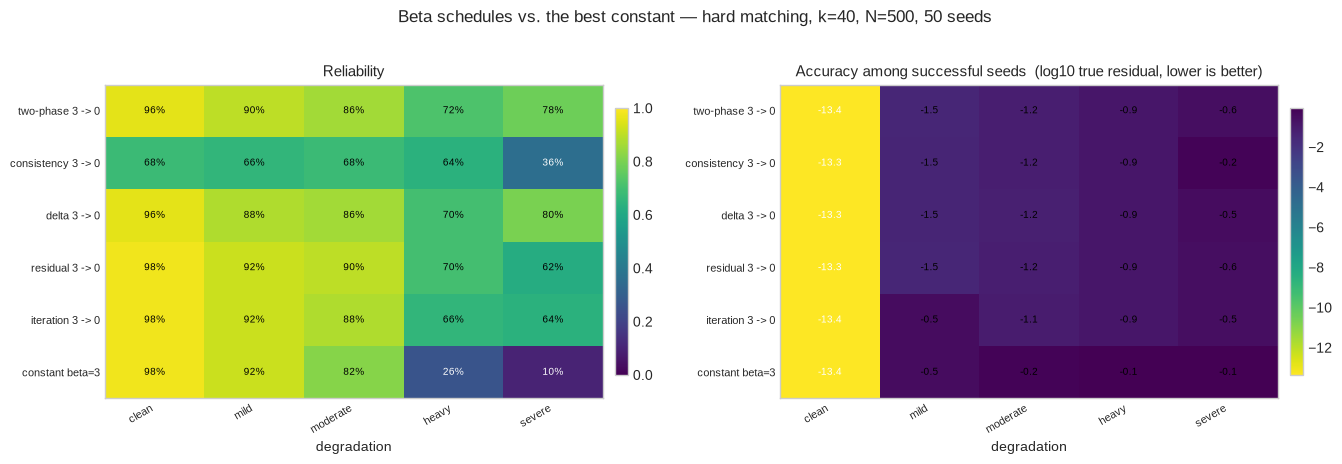

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

image = SweepVisualizer.plot_heatmap(
    axes[0], reliability, x_labels=level_labels, y_labels=list(SCHEDULES),
    x_label='degradation', y_label='', title='Reliability',
    value_format='.0%', vmin=0.0, vmax=1.0,
)
fig.colorbar(image, ax=axes[0], shrink=0.85, pad=0.02)

# Accuracy spans orders of magnitude between the clean and degraded ends, so it is shown
# on a log scale; a linear one would render every clean column as an identical zero.
with np.errstate(divide='ignore'):
    log_accuracy = np.log10(np.where(accuracy > 0, accuracy, np.nan))
image = SweepVisualizer.plot_heatmap(
    axes[1], log_accuracy, x_labels=level_labels, y_labels=list(SCHEDULES),
    x_label='degradation', y_label='',
    title='Accuracy among successful seeds  (log10 true residual, lower is better)',
    value_format='.1f', cmap='viridis_r',
)
fig.colorbar(image, ax=axes[1], shrink=0.85, pad=0.02)

fig.suptitle(f'Beta schedules vs. the best constant — hard matching, k={FE_K}, '
             f'N={N_POINTS}, {N_SEEDS} seeds', y=1.02)
fig.tight_layout()
fig.savefig('../results/4_3_schedules_vs_constant.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations — schedules vs. constant

**Annealing does not help where the constant already works; it rescues the cases where
the constant collapses.**

| | clean | mild | moderate | heavy | severe |
|---|---|---|---|---|---|
| constant β=3 | 98% | 92% | 82% | **26%** | **10%** |
| iteration 3→0 | 98% | 92% | 88% | 66% | 64% |
| residual 3→0 | 98% | 92% | **90%** | 70% | 62% |
| delta 3→0 | 96% | 88% | 86% | 70% | **80%** |
| consistency 3→0 | 68% | 66% | 68% | 64% | 36% |
| two-phase 3→0 | 96% | 90% | 86% | **72%** | 78% |

At clean and mild everything is within a few points, and annealing costs 2 points if
anything. At heavy and severe the constant falls to 26% and 10% while every schedule but
consistency holds 62–80% — a **three- to eightfold** improvement. This is the degradation
ceiling from 4.2 being lifted: a constant `beta` that survives severe degradation must be
low enough to be useless for the search, whereas a schedule can be high while searching
and low afterwards.

**Accuracy improves by roughly an order of magnitude, everywhere it can.** Among the runs
that reached the global optimum, the median true residual at moderate degradation falls
from **0.63** to **0.062**. This is the second pull from 4.2 — at the optimum, positions
alone pair every point correctly and features can only interfere — and a
reliability-only comparison would not have shown it at all.

**Consistency is the outlier, and it is instructive.** With its thresholds calibrated it
matches the others on accuracy (0.063 at moderate) but loses 14–20 points of reliability
everywhere, including on clean data. The distinct-target fraction rises early — it is
already 0.6 at iteration 0, against a settled value of 0.63 — so the schedule reads
"converged" almost immediately and drops `beta` before the search is done. It measures
correspondence quality honestly, but it saturates too early in the run to time a
schedule with.

**The two-phase switch matches the graded schedules.** 72% and 78% at heavy and severe,
against 70%/80% for the delta schedule it is a crude version of. On this evidence the
graded curve is not earning its extra parameters: what matters is *whether* `beta` drops
after the search, not how smoothly.

## 3. How sensitive is a schedule to its starting `beta`?

A schedule removes the need to choose `beta` for the *whole* run, but not the need to
choose where it starts. That choice is bounded by descriptor quality rather than by
misalignment, and notebook 4.2 showed the bound is sharp in one direction: reliability
fell from 82% at `beta=3` to 6% at `beta=12` under degradation. Undershooting costs far
less than overshooting.

The question is whether annealing *widens* that window. A schedule that comes down
quickly might tolerate a start well above the best constant, since the damage a too-high
`beta` does is concentrated in the iterations it stays there — which would make the
starting value much less delicate to pick, and that is worth more in practice than a few
points of reliability.

In [6]:
BETA_STARTS = [1.0, 2.0, 3.0, 5.0, 8.0, 12.0]


def schedule_for(name: str, beta_start: float) -> ICPCallback | None:
    """Build one schedule at a given starting weight.

    Args:
        name:       Which schedule to build.
        beta_start: Feature weight the run starts from.

    Returns:
        The callback, or None for the constant-beta reference.

    Raises:
        ValueError: If the schedule name is unknown.
    """
    if name == 'constant':
        return None
    if name == 'iteration':
        return IterationBetaAnnealing(beta_start, 0.0, MAX_ITER)
    if name == 'residual':
        return ResidualBetaAnnealing(beta_start, 0.0, start_spacings=5.0, end_spacings=2.3)
    if name == 'delta':
        return DeltaBetaAnnealing(beta_start, 0.0, end_fraction=0.05)
    if name == 'consistency':
        return ConsistencyBetaAnnealing(beta_start, 0.0,
                                        start_uniqueness=0.5, end_uniqueness=0.63)
    if name == 'two-phase':
        return TwoPhaseBetaAnnealing(beta_start, 0.0, stall_delta=5.0)
    raise ValueError(f'Unknown schedule: {name}')


START_SWEEP_LEVEL = 'moderate'  # where 4.2 put the constant's optimum near 3
schedule_names = ['constant', 'iteration', 'residual', 'delta', 'consistency', 'two-phase']
start_reliability = np.zeros((len(schedule_names), len(BETA_STARTS)))
for i, name in enumerate(tqdm(schedule_names, desc='beta_start sweep')):
    for j, beta_start in enumerate(BETA_STARTS):
        start_reliability[i, j], _ = evaluate(
            schedule_for(name, beta_start), DEGRADATION_LEVELS[START_SWEEP_LEVEL],
            tolerance_for(START_SWEEP_LEVEL), beta=beta_start,
        )

print(f'Reliability at {START_SWEEP_LEVEL} degradation, by starting beta')
print(tabulate([[n] + [f'{start_reliability[i, j]:.0%}' for j in range(len(BETA_STARTS))]
                for i, n in enumerate(schedule_names)],
               headers=[''] + [f'beta={b:g}' for b in BETA_STARTS], tablefmt='rounded_outline'))


beta_start sweep:   0%|          | 0/6 [00:00<?, ?it/s]


beta_start sweep:  17%|█▋        | 1/6 [00:29<02:29, 29.88s/it]


beta_start sweep:  33%|███▎      | 2/6 [03:40<08:18, 124.69s/it]


beta_start sweep:  50%|█████     | 3/6 [04:12<04:06, 82.23s/it] 


beta_start sweep:  67%|██████▋   | 4/6 [04:52<02:10, 65.33s/it]


beta_start sweep:  83%|████████▎ | 5/6 [05:23<00:53, 53.24s/it]


beta_start sweep: 100%|██████████| 6/6 [05:58<00:00, 47.06s/it]


beta_start sweep: 100%|██████████| 6/6 [05:58<00:00, 59.82s/it]

Reliability at moderate degradation, by starting beta
╭─────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬───────────╮
│             │ beta=1   │ beta=2   │ beta=3   │ beta=5   │ beta=8   │ beta=12   │
├─────────────┼──────────┼──────────┼──────────┼──────────┼──────────┼───────────┤
│ constant    │ 42%      │ 72%      │ 82%      │ 56%      │ 24%      │ 16%       │
│ iteration   │ 38%      │ 72%      │ 88%      │ 86%      │ 76%      │ 38%       │
│ residual    │ 30%      │ 72%      │ 90%      │ 92%      │ 28%      │ 16%       │
│ delta       │ 34%      │ 66%      │ 86%      │ 94%      │ 100%     │ 100%      │
│ consistency │ 40%      │ 56%      │ 68%      │ 82%      │ 96%      │ 100%      │
│ two-phase   │ 36%      │ 68%      │ 86%      │ 92%      │ 100%     │ 100%      │
╰─────────────┴──────────┴──────────┴──────────┴──────────┴──────────┴───────────╯


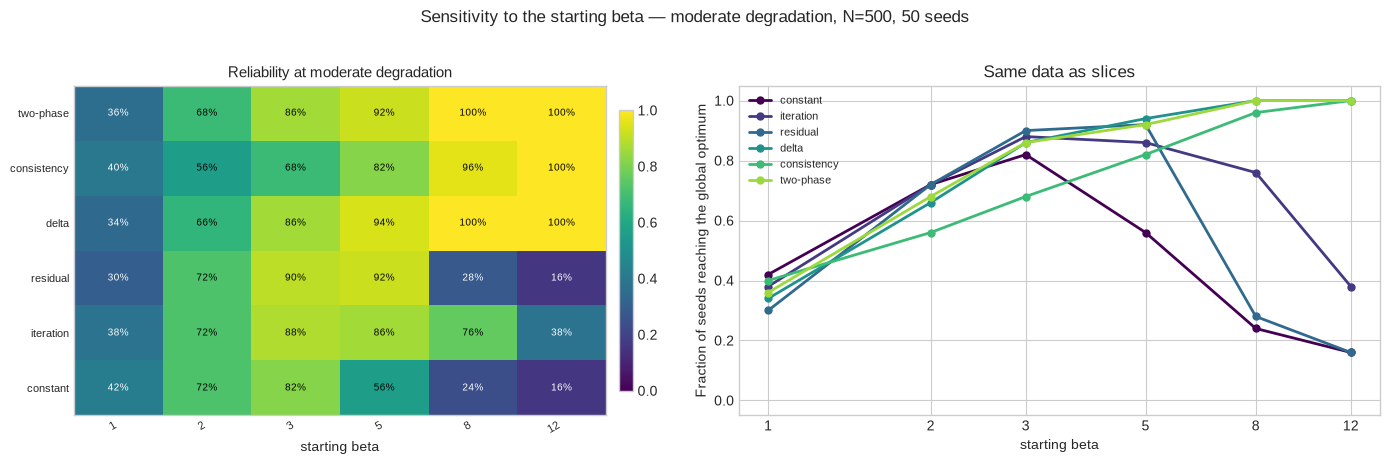

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

image = SweepVisualizer.plot_heatmap(
    axes[0], start_reliability,
    x_labels=[f'{b:g}' for b in BETA_STARTS], y_labels=schedule_names,
    x_label='starting beta', y_label='', title=f'Reliability at {START_SWEEP_LEVEL} degradation',
    value_format='.0%', vmin=0.0, vmax=1.0,
)
fig.colorbar(image, ax=axes[0], shrink=0.85, pad=0.02)

# Slices show how sharp each optimum is, which is the practical question: a flat curve
# means the starting value barely needs choosing.
ax = axes[1]
shades = plt.cm.viridis(np.linspace(0.0, 0.85, len(schedule_names)))
for i, name in enumerate(schedule_names):
    ax.plot(BETA_STARTS, start_reliability[i], marker='o', ms=5, linewidth=2,
            color=shades[i], label=name)
ax.set_xscale('log')
ax.set_xticks(BETA_STARTS)
ax.set_xticklabels([f'{b:g}' for b in BETA_STARTS])
ax.set_xlabel('starting beta')
ax.set_ylabel('Fraction of seeds reaching the global optimum')
# Headroom past 0 and 1 so a saturated curve is not drawn half outside the axes.
ax.set_ylim(-0.05, 1.05)
ax.set_title('Same data as slices')
ax.legend(fontsize=8)

fig.suptitle(f'Sensitivity to the starting beta — {START_SWEEP_LEVEL} degradation, '
             f'N={N_POINTS}, {N_SEEDS} seeds', y=1.02)
fig.tight_layout()
fig.savefig('../results/4_3_beta_start_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations — sensitivity to the start

**This is the most useful result in the notebook.** Annealing does not merely shift the
optimal `beta` — for the schedules that trigger on motion stopping, it removes the
overshoot cliff altogether.

| starting β | 1 | 2 | 3 | 5 | 8 | 12 |
|---|---|---|---|---|---|---|
| constant | 42% | 72% | **82%** | 56% | 24% | 16% |
| iteration | 38% | 72% | 88% | 86% | 76% | 38% |
| residual | 30% | 72% | 90% | **92%** | 28% | 16% |
| delta | 34% | 66% | 86% | 94% | **100%** | **100%** |
| consistency | 40% | 56% | 68% | 82% | 96% | **100%** |
| two-phase | 36% | 68% | 86% | 92% | **100%** | **100%** |

With a constant, `beta = 12` is catastrophic (16%) and the optimum is a narrow peak at 3
that has to be found by search. With delta-driven or two-phase annealing, `beta = 12` is
*optimal* — 100%, against 82% for the best constant anywhere. The parameter stops being
delicate: "start as high as you can afford" becomes simply correct, which is worth more
in practice than the 18 points of reliability, because it is a rule that transfers to
data whose degradation level is unknown.

**The dividing line is what the signal measures.** The three schedules that tolerate a
high start — delta, two-phase, consistency — all trigger on some form of *"the search has
finished"*. The two that do not — constant by definition, and residual-driven, which
collapses to 28% at `beta=8` — are driven by *"how far off am I"*. A high `beta` is only
safe if something reliably takes it away afterwards, and a closest-point residual that
bottoms out at 2.4 spacings never gives a clean enough signal to do so.

**The iteration schedule sits in between**, degrading gracefully (76% at 8, 38% at 12)
rather than collapsing. It always removes `beta` eventually, which protects it — but on a
timetable rather than on evidence, so a very high start is still up for too long.

## Summary

1. **Annealing `beta` beats the best constant, on both axes.** Reliability at heavy and
   severe degradation goes from 26%/10% to about 70%/80%; accuracy among successful runs
   improves roughly tenfold (0.63 → 0.062 at moderate). The two gains come from opposite
   ends of the run, exactly as 4.1 §5 and 4.2 §2 predicted: high `beta` early finds the
   basin, low `beta` late refines inside it.
2. **The trigger should detect that the search has finished, not how far off the fit is.**
   Delta-driven and two-phase annealing tolerate — and prefer — a starting `beta` of 8–12,
   reaching 100% where the best constant reaches 82%. Residual-driven annealing collapses
   at the same starting values, because a closest-point residual bottoms out at 2.4 point
   spacings and never signals completion cleanly.
3. **The practical win is not the reliability points, it is the disappearance of the
   cliff.** With a constant, `beta` is a narrow peak that must be tuned to a degradation
   level you do not know on real data. With motion-triggered annealing, "start high" is
   simply the right answer.
4. **A smooth schedule is not obviously worth it.** The two-phase switch matches the
   graded delta schedule to within a couple of points everywhere. What matters is whether
   `beta` comes off after the search, not how gradually.

**A trap worth recording.** A schedule that clamps `beta` non-increasing carries state,
and `fit_multi_seed` reuses one callback instance across every seed. Without a reset, the
clamp from seed 1 caps seed 2, and `beta` ratchets down across the sweep until later seeds
run at nearly zero — which looks exactly like "annealing hurts reliability" and is entirely
an artifact. `ICP.fit` now calls `ICPCallback.reset()` before the first iteration, pinned
by `test_fit_resets_schedules_between_runs`. The first run of this notebook measured
schedules as 50 points *worse* than the constant for this reason alone.

**A second trap, visible in §1.** A schedule interpolating towards a threshold its signal
never reaches stops part-way and silently becomes a lower constant. Both threshold-based
schedules were initially configured that way. Calibrating them against the measured
trajectories changed consistency's accuracy at severe degradation from 0.82 to 0.65 and
its high-`beta` reliability from 28% to 100%.

**What this leaves open.** The starting `beta` still has a ceiling set by descriptor
quality, and nothing here estimates it — `beta=12` is optimal at moderate degradation but
4.2 showed high `beta` collapsing under severe degradation, so the ceiling is real and
merely out of reach of this sweep. A runtime estimate is possible: comparing the feature
distances of mutually consistent pairs against random pairs would say how far the
descriptor can be trusted before the first iteration runs.